# Attention U-Net (HR Net Encoder) — Prostate Zonal Segmentation

**Dataset verified:**
- 98 patients, all 4 zones present for every patient
- MRI: `mri/ProstateX-XXXX/ProstateX-XXXX_0000.nii.gz` shape (384,384,N) int16
- Masks: `masks/ProstateX-XXXX/{AFMS,PZ,TZ,ProstaticUrethra}.nii.gz`
  - Each file stores its own native label as nonzero (AFMS→4, PZ→1, TZ→2, Urethra→3)
  - We threshold `> 0` and remap via ZONE_MAP to our scheme
- No voxel overlaps between zones confirmed

**Our class scheme:** 0=Background | 1=AFMS | 2=PZ | 3=TZ | 4=ProstaticUrethra

**Pipeline:** Patient-level 80/20 split → 5-fold CV on train patients → best_model.pth → test evaluation

In [1]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [2]:
import torch

print("PyTorch Imported Successfully!")
print("CUDA Available:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
#import torch
#print("PyTorch Version:", torch.__version__)


PyTorch Imported Successfully!
CUDA Available: True
Device Name: NVIDIA T400 4GB


In [2]:
import os, gc, json, random, shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import nibabel as nib
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import timm 
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix

SAVE_DIR = "AttentionUNet_HRNetW32"
for d in [SAVE_DIR, os.path.join(SAVE_DIR, 'checkpoints'), 
          os.path.join(SAVE_DIR, 'plots'), os.path.join(SAVE_DIR, 'visuals')]:
    os.makedirs(d, exist_ok=True)
print(f"Output folder ready: {SAVE_DIR}/")

d:\BT23ECE038_JAY_FYP\BT22ECE075-Shreya\BT22ECE075-Shreya\Prostate-Gland-Zonal-Segmentation\UNet 2Ds\.venv1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Output folder ready: AttentionUNet_HRNetW32/


In [3]:
MRI_ROOT = r"D:\BT23ECE038_JAY_FYP\BT22ECE075-Shreya\BT22ECE075-Shreya\models\dataset nifti\mri"
SEG_ROOT = r"D:\BT23ECE038_JAY_FYP\BT22ECE075-Shreya\BT22ECE075-Shreya\models\dataset nifti\masks"

ZONE_MAP = {"AFMS": 1, "PZ": 2, "TZ": 3, "ProstaticUrethra": 4}
CLASS_NAMES = ['Background', 'AFMS', 'PZ', 'TZ', 'ProstaticUrethra']
NUM_CLASSES = 5
TARGET_SIZE = (320, 320)

DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE  = 2
EPOCHS      = 50
LR          = 1e-4
K_FOLDS     = 5
TEST_SPLIT  = 0.20
SEED        = 42

CLASS_WEIGHTS = torch.tensor([0.05, 0.30, 0.20, 0.15, 0.30]).to(DEVICE)
SAVE_PREFIX   = os.path.join(SAVE_DIR, 'checkpoints', 'attn_unet_hrnetw32')

print(f"Device: {DEVICE} | Target: {TARGET_SIZE} | Model: HRNet-W32")

Device: cuda | Target: (320, 320) | Model: HRNet-W32


In [4]:
# =============================================================================
# CELL 3 — Dataset
# =============================================================================
class ProstateZonalDataset(Dataset):
    """
    2-D slice dataset for prostate zonal segmentation from NIfTI files.

    Verified layout:
        mri/ProstateX-XXXX/ProstateX-XXXX_0000.nii.gz   shape (H,W,S) int16
        masks/ProstateX-XXXX/AFMS.nii.gz                 nonzero=4, binary
        masks/ProstateX-XXXX/PZ.nii.gz                   nonzero=1, binary
        masks/ProstateX-XXXX/TZ.nii.gz                   nonzero=2, binary
        masks/ProstateX-XXXX/ProstaticUrethra.nii.gz     nonzero=3, binary

    All zone files exist for all 98 patients. No voxel overlaps.
    """

    def __init__(self, mri_root, seg_root, patient_ids,
                 zone_map, target_size=(320, 320)):
        self.mri_root    = mri_root
        self.seg_root    = seg_root
        self.zone_map    = zone_map
        self.target_size = target_size
        self.patient_ids = list(patient_ids)

        self.slice_index = []   # list of (patient_id, slice_idx)
        for pid in self.patient_ids:
            mri_path = os.path.join(mri_root, pid, f"{pid}_0000.nii.gz")
            n_slices = nib.load(mri_path).shape[-1]
            for s in range(n_slices):
                self.slice_index.append((pid, s))

        print(f"  {len(self.patient_ids)} patients, {len(self.slice_index)} slices")

    def __len__(self):
        return len(self.slice_index)

    def _load_volume(self, pid):
        # MRI — z-score normalise per volume
        mri = nib.load(
            os.path.join(self.mri_root, pid, f"{pid}_0000.nii.gz")
        ).get_fdata().astype(np.float32)
        mri = (mri - mri.mean()) / (mri.std() + 1e-8)

        # Multi-class mask: start all-zero, write each zone via threshold > 0
        mask = np.zeros(mri.shape, dtype=np.uint8)
        seg_folder = os.path.join(self.seg_root, pid)
        for zone_name, class_id in self.zone_map.items():
            seg_path = os.path.join(seg_folder, f"{zone_name}.nii.gz")
            if os.path.exists(seg_path):
                seg = np.squeeze(
                    nib.load(seg_path).get_fdata()
                ).astype(np.float32)
                # threshold > 0 ignores the file's native label value
                mask[seg > 0] = class_id

        return mri, mask

    def __getitem__(self, idx):
        pid, s    = self.slice_index[idx]
        mri, mask = self._load_volume(pid)

        img  = torch.tensor(mri[:, :, s],        dtype=torch.float32).unsqueeze(0)
        msk  = torch.tensor(mask[:, :, s].copy(), dtype=torch.long)

        img = F.interpolate(img.unsqueeze(0), size=self.target_size,
                            mode='bilinear', align_corners=False).squeeze(0)
        msk = F.interpolate(msk.unsqueeze(0).unsqueeze(0).float(),
                            size=self.target_size,
                            mode='nearest').squeeze().long()
        
        # ADDED: Return identifiers for tracking
        return img, msk, pid, s


def get_all_patient_ids(mri_root):
    return sorted([
        f for f in os.listdir(mri_root)
        if os.path.isdir(os.path.join(mri_root, f)) and not f.startswith('.')
    ])


# Patient-level 80/20 split
all_patients = get_all_patient_ids(MRI_ROOT)
random.seed(SEED)
random.shuffle(all_patients)

n_test            = max(1, int(len(all_patients) * TEST_SPLIT))
test_patients     = all_patients[:n_test]
trainval_patients = all_patients[n_test:]

print(f"Total: {len(all_patients)} | Train+Val: {len(trainval_patients)} | Test: {len(test_patients)}")
print("Building datasets...")
trainval_dataset = ProstateZonalDataset(MRI_ROOT, SEG_ROOT, trainval_patients, ZONE_MAP, TARGET_SIZE)
test_dataset     = ProstateZonalDataset(MRI_ROOT, SEG_ROOT, test_patients,     ZONE_MAP, TARGET_SIZE)

Total: 98 | Train+Val: 79 | Test: 19
Building datasets...
  79 patients, 1627 slices
  19 patients, 393 slices


Sanity Check: Patient ProstateX-0102, Slice 1
Image : shape=(1, 320, 320) min=-1.20 max=3.76
Mask  : shape=(320, 320) unique=[0, 4]


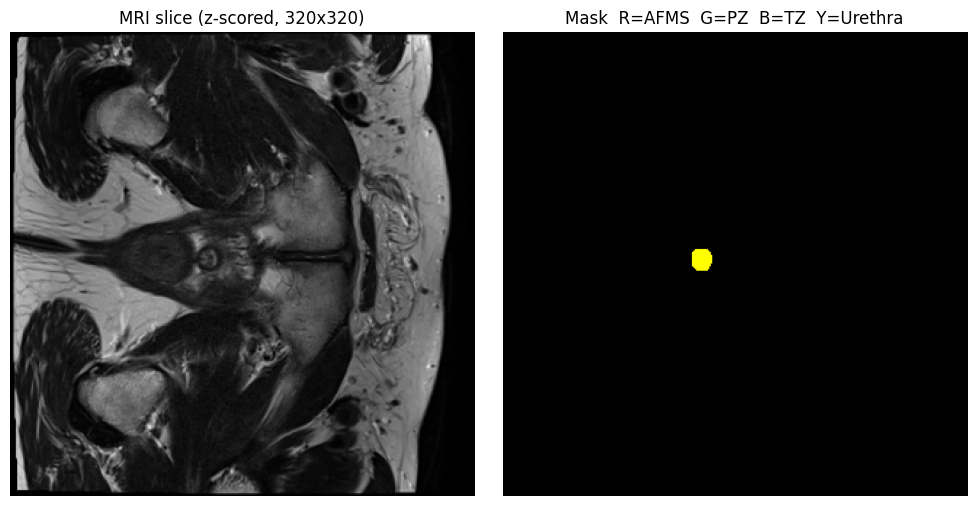

5

In [5]:
# =============================================================================
# CELL 4 — Quick dataset sanity check
# =============================================================================
import os
import gc
# Fixes the silent Windows Matplotlib/PyTorch crash
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True' 

COLORS = np.array([
    [0,   0,   0  ],   # Background — black
    [0,   0,   255],   # AFMS       — blue
    [255, 0,   0  ],   # PZ         — red
    [0,   255, 0  ],   # TZ         — green
    [255, 255, 0  ],   # Urethra    — yellow
], dtype=np.uint8)

# Clear RAM before loading the volume
gc.collect()

img, mask, pid, s = trainval_dataset[1]

print(f"Sanity Check: Patient {pid}, Slice {s}")
print(f"Image : shape={tuple(img.shape)} min={img.min():.2f} max={img.max():.2f}")
print(f"Mask  : shape={tuple(mask.shape)} unique={mask.unique().tolist()}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img[0].numpy(), cmap='gray')
axes[0].set_title('MRI slice (z-scored, 320x320)')
axes[0].axis('off')

axes[1].imshow(COLORS[mask.numpy()])
axes[1].set_title('Mask  R=AFMS  G=PZ  B=TZ  Y=Urethra')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'plots', 'sample_slice.png'), dpi=150, bbox_inches='tight')
plt.show()

# Free memory immediately after plotting
del img, mask
gc.collect()

In [13]:
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1, bias=True), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1, bias=True), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1, bias=True), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        if g.shape[-2:] != x.shape[-2:]:
            g = F.interpolate(g, size=x.shape[-2:], mode='bilinear', align_corners=False)
        return x * self.psi(self.relu(self.W_g(g) + self.W_x(x)))

class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        
        # Protect against F_int dropping to 0
        self.attention = AttentionGate(F_g=out_ch, F_l=skip_ch, F_int=max(1, out_ch // 2))
        
        self.conv = nn.Sequential(
            nn.Conv2d(out_ch + skip_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        x = self.up(x)
        # Safety alignment in case HRNet pads irregularly
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
            
        skip_att = self.attention(x, skip)
        return self.conv(torch.cat([skip_att, x], dim=1))

class AttentionUNetHRNetW32(nn.Module):
    def __init__(self, num_classes=5, pretrained=False):
        super().__init__()
        
        # 1. Load HRNet W32 backbone (pretrained=False as requested)
        self.encoder = timm.create_model('hrnet_w32', pretrained=pretrained, features_only=True)
        
        # Modify for 1-channel MRI input
        self.encoder.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=2, padding=1, bias=False)

        # 2. Dynamic channel extraction to guarantee [64, 128, 256, 512, 1024]
        with torch.no_grad():
            dummy = torch.randn(1, 1, 320, 320)
            feats = self.encoder(dummy)
            channels = [f.shape[1] for f in feats]
        
        ch1, ch2, ch3, ch4, ch5 = channels
        
        # 3. Build 4 Decoder stages using the extracted channels
        self.dec4 = DecoderBlock(in_ch=ch5, skip_ch=ch4, out_ch=ch4) # 1024 -> 512
        self.dec3 = DecoderBlock(in_ch=ch4, skip_ch=ch3, out_ch=ch3) # 512 -> 256
        self.dec2 = DecoderBlock(in_ch=ch3, skip_ch=ch2, out_ch=ch2) # 256 -> 128
        self.dec1 = DecoderBlock(in_ch=ch2, skip_ch=ch1, out_ch=ch1) # 128 -> 64
        
        # 4. Final upsampling to original target size (320x320)
        # HRNet stem is stride 2, so we need one more 2x upsample
        self.final_up = nn.Sequential(
            nn.ConvTranspose2d(ch1, 32, kernel_size=2, stride=2), 
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True)
        )
        self.head = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        input_shape = x.shape[-2:]
        
        # Unpack exactly 5 feature maps: [64, 128, 256, 512, 1024]
        e1, e2, e3, e4, e5 = self.encoder(x) 

        # Decoder stream
        d4 = self.dec4(e5, e4)
        d3 = self.dec3(d4, e3)
        d2 = self.dec2(d3, e2)
        d1 = self.dec1(d2, e1)

        out = self.final_up(d1)
        
        # Force exact input resolution to avoid edge-case crashes
        if out.shape[-2:] != input_shape:
            out = F.interpolate(out, size=input_shape, mode='bilinear', align_corners=False)
            
        return self.head(out)

# Model initialization sanity check
model = AttentionUNetHRNetW32(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)
print(f"HRNet-W32 Encoder Model Loaded. Total params: {sum(p.numel() for p in model.parameters()):,}")

# Pass a dummy tensor to guarantee it doesn't crash before you run the k-fold loop
with torch.no_grad():
    dummy_out = model(torch.randn(1, 1, 320, 320).to(DEVICE))
    print(f"Verified Output Shape: {tuple(dummy_out.shape)}")

HRNet-W32 Encoder Model Loaded. Total params: 43,440,369
Verified Output Shape: (1, 5, 320, 320)


In [14]:
# =============================================================================
# CELL 6 — Loss (Dice + Focal  alpha=0.25  gamma=2) & batch Dice
# =============================================================================
class DiceLoss(nn.Module):
    def __init__(self, n_classes, weights=None, smooth=1e-6):
        super().__init__()
        self.n_classes = n_classes; self.weights = weights; self.smooth = smooth

    def forward(self, inputs, targets):
        probs = F.softmax(inputs, dim=1)
        t_oh  = F.one_hot(targets, self.n_classes).permute(0,3,1,2).float()
        dims  = (0, 2, 3)
        inter = torch.sum(probs * t_oh, dims)
        card  = torch.sum(probs + t_oh, dims)
        dc    = 1.0 - (2.0*inter + self.smooth) / (card + self.smooth)
        return (dc * self.weights).mean() if self.weights is not None else dc.mean()


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, class_weights=None):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma; self.class_weights = class_weights

    def forward(self, inputs, targets):
        ce    = F.cross_entropy(inputs, targets, weight=self.class_weights, reduction='none')
        focal = self.alpha * (1 - torch.exp(-ce)) ** self.gamma * ce
        return focal.mean()


class DiceFocalLoss(nn.Module):
    def __init__(self, n_classes, class_weights=None):
        super().__init__()
        self.dice  = DiceLoss(n_classes, weights=class_weights)
        self.focal = FocalLoss(alpha=0.25, gamma=2.0, class_weights=class_weights)

    def forward(self, inputs, targets):
        return self.dice(inputs, targets) + self.focal(inputs, targets)


def get_batch_dice(preds, targets, num_classes):
    pred_cls = torch.argmax(F.softmax(preds, dim=1), dim=1)
    return [
        ((2*(pred_cls==c).float()*(targets==c).float()).sum() + 1e-6) /
        ((pred_cls==c).float().sum() + (targets==c).float().sum() + 1e-6)
        for c in range(num_classes)
    ]

In [15]:
# =============================================================================
# CELL 7 — Single-fold training (Updated with Early Stopping)
# =============================================================================
def train_one_fold(model, train_loader, val_loader, epochs, save_prefix, fold_idx):
    model     = model.to(DEVICE)
    criterion = DiceFocalLoss(n_classes=NUM_CLASSES, class_weights=CLASS_WEIGHTS)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    history = {
        'train_loss': [], 'val_loss': [],
        **{f'train_dice_{n.lower()}': [] for n in CLASS_NAMES},
        **{f'val_dice_{n.lower()}':   [] for n in CLASS_NAMES},
    }
    best_val_loss = float('inf'); best_epoch = 0
    
    # ADDED: Early stopping trackers
    early_stop_patience = 10  # Stop if no improvement for 10 epochs
    patience_counter = 0

    for epoch in range(epochs):
        # ── Train ────────────────────────────────────────────────────────
        model.train()
        tr_loss = 0.0; tr_dices = [0.0]*NUM_CLASSES
        loop = tqdm(train_loader, leave=False,
                    desc=f"Fold {fold_idx+1} | Ep {epoch+1}/{epochs} TRAIN")
        
        for imgs, masks, pids, sls in loop:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, masks)
            loss.backward(); optimizer.step()
            bd = get_batch_dice(out.detach(), masks, NUM_CLASSES)
            tr_loss += loss.item()
            for c in range(NUM_CLASSES): tr_dices[c] += bd[c].item() if hasattr(bd[c],'item') else bd[c]
            loop.set_postfix(loss=f"{loss.item():.3f}",
                             **{CLASS_NAMES[c]: f"{bd[c]:.2f}" for c in range(1, NUM_CLASSES)})

        n_tr = len(train_loader)
        avg_tr_loss  = tr_loss / n_tr
        avg_tr_dices = [d/n_tr for d in tr_dices]

        # ── Validate ─────────────────────────────────────────────────────
        model.eval()
        va_loss = 0.0; va_dices = [0.0]*NUM_CLASSES
        with torch.no_grad():
            for imgs, masks, pids, sls in tqdm(val_loader, leave=False,
                                    desc=f"Fold {fold_idx+1} | Ep {epoch+1}/{epochs} VAL"):
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                out = model(imgs)
                va_loss += criterion(out, masks).item()
                bd = get_batch_dice(out, masks, NUM_CLASSES)
                for c in range(NUM_CLASSES): va_dices[c] += bd[c].item() if hasattr(bd[c],'item') else bd[c]

        n_va = len(val_loader)
        avg_va_loss  = va_loss / n_va
        avg_va_dices = [d/n_va for d in va_dices]

        print(f"\n  Fold {fold_idx+1} | Epoch {epoch+1}/{epochs}")
        print(f"    TRAIN loss={avg_tr_loss:.4f}  " +
              "  ".join(f"{n}:{avg_tr_dices[i]:.3f}" for i,n in enumerate(CLASS_NAMES)))
        print(f"    VAL   loss={avg_va_loss:.4f}  " +
              "  ".join(f"{n}:{avg_va_dices[i]:.3f}" for i,n in enumerate(CLASS_NAMES)))

        # Learning Rate tracking
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(avg_va_loss)
        new_lr = optimizer.param_groups[0]['lr']
        if new_lr < old_lr:
            print(f"    Epoch {epoch+1}: reducing learning rate to {new_lr:.2e}.")

        # CHANGED: Early stopping logic
        if avg_va_loss < best_val_loss:
            best_val_loss = avg_va_loss; best_epoch = epoch+1
            torch.save(model.state_dict(), f"{save_prefix}_fold{fold_idx+1}_best.pth")
            print(f"    Best model saved (val_loss={best_val_loss:.4f})")
            patience_counter = 0  # Reset counter when we get a new best
        else:
            patience_counter += 1
            print(f"    Early stopping counter: {patience_counter} out of {early_stop_patience}")
            if patience_counter >= early_stop_patience:
                print("    Early stopping triggered! Moving to next fold.")
                break  # Escapes the epoch loop early

        # Save checkpoint every 5 epochs
        if (epoch+1) % 5 == 0:
            ck = f"{save_prefix}_fold{fold_idx+1}_epoch{epoch+1}.pth"
            torch.save(model.state_dict(), ck)
            print(f"    Checkpoint: {ck}")

        history['train_loss'].append(avg_tr_loss)
        history['val_loss'].append(avg_va_loss)
        for i,n in enumerate(CLASS_NAMES):
            history[f'train_dice_{n.lower()}'].append(avg_tr_dices[i])
            history[f'val_dice_{n.lower()}'].append(avg_va_dices[i])
        
        # Save metrics
        with open(f"{save_prefix}_fold{fold_idx+1}_metrics.json", 'w') as f:
            json.dump(history, f)

        torch.cuda.empty_cache(); gc.collect()

    return history, best_val_loss, best_epoch

In [11]:
# =============================================================================
# CELL 8 — K-fold runner (Windows-Compatible Version)
# =============================================================================
def run_kfold(trainval_patients, k=K_FOLDS, epochs=EPOCHS, save_prefix=SAVE_PREFIX):
    kf = KFold(n_splits=k, shuffle=True, random_state=SEED)
    patient_arr = np.array(trainval_patients)
    fold_histories = []; fold_best = []
    global_best_loss = float('inf'); global_best_path = None

    for fold_idx, (tr_idx, va_idx) in enumerate(kf.split(patient_arr)):
        print("\n" + "="*70)
        print(f"  FOLD {fold_idx+1}/{k}  train={len(tr_idx)} patients  val={len(va_idx)} patients")
        print("="*70)

        tr_ds = ProstateZonalDataset(MRI_ROOT, SEG_ROOT,
                                     patient_arr[tr_idx].tolist(), ZONE_MAP, TARGET_SIZE)
        va_ds = ProstateZonalDataset(MRI_ROOT, SEG_ROOT,
                                     patient_arr[va_idx].tolist(), ZONE_MAP, TARGET_SIZE)
        
        # CHANGED: num_workers set to 0 for Windows stability
        tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=0, pin_memory=True)
        va_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=0, pin_memory=True)

        model = AttentionUNetHRNetW32(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)
        history, best_loss, best_ep = train_one_fold(
            model, tr_loader, va_loader, epochs, save_prefix, fold_idx)
        fold_histories.append(history)

        fold_best.append({
            'fold': fold_idx+1, 'best_epoch': best_ep, 'val_loss': best_loss,
            **{n: history[f'val_dice_{n.lower()}'][best_ep-1] for n in CLASS_NAMES},
        })
        if best_loss < global_best_loss:
            global_best_loss = best_loss
            global_best_path = f"{save_prefix}_fold{fold_idx+1}_best.pth"

        del model, tr_ds, va_ds
        torch.cuda.empty_cache(); gc.collect()

    fg_names = CLASS_NAMES[1:]
    print("\n" + "="*70 + "\n  K-FOLD SUMMARY\n" + "="*70)
    for fd in fold_best:
        print(f"  Fold {fd['fold']} (ep {fd['best_epoch']}) ValLoss={fd['val_loss']:.4f} | " +
              " | ".join(f"{n}:{fd[n]:.4f}" for n in CLASS_NAMES))

    mean_d = {n: float(np.mean([fd[n] for fd in fold_best])) for n in CLASS_NAMES}
    std_d  = {n: float(np.std( [fd[n] for fd in fold_best])) for n in CLASS_NAMES}
    mean_dice_fg = float(np.mean([mean_d[n] for n in fg_names]))
    print("\n  Mean +/- Std:")
    for n in CLASS_NAMES: print(f"    {n:22s}: {mean_d[n]:.4f} +/- {std_d[n]:.4f}")
    print(f"    {'Mean Dice (FG)':22s}: {mean_dice_fg:.4f}")

    summary = {'per_fold': fold_best, 'mean': mean_d, 'std': std_d, 'mean_dice_fg': mean_dice_fg}
    with open(f"{save_prefix}_kfold_summary.json", 'w') as f: json.dump(summary, f, indent=2)

    best_dest = os.path.join(SAVE_DIR, 'best_model.pth')
    shutil.copy(global_best_path, best_dest)
    print(f"\n  Global best -> {best_dest}  (val_loss={global_best_loss:.4f})")
    return fold_histories, summary, best_dest

# REQUIRED: Wrap execution in main to prevent DataLoader worker crashes
if __name__ == '__main__':
    fold_histories, kfold_summary, best_model_path = run_kfold(trainval_patients)
    print(f"\nBest model: {best_model_path}")


  FOLD 1/5  train=63 patients  val=16 patients
  63 patients, 1295 slices
  16 patients, 332 slices


Unexpected keys (downsamp_modules.0.1.num_batches_tracked, downsamp_modules.1.1.num_batches_tracked, downsamp_modules.2.1.num_batches_tracked, final_layer.1.num_batches_tracked, downsamp_modules.0.0.bias, downsamp_modules.0.0.weight, downsamp_modules.0.1.bias, downsamp_modules.0.1.running_mean, downsamp_modules.0.1.running_var, downsamp_modules.0.1.weight, downsamp_modules.1.0.bias, downsamp_modules.1.0.weight, downsamp_modules.1.1.bias, downsamp_modules.1.1.running_mean, downsamp_modules.1.1.running_var, downsamp_modules.1.1.weight, downsamp_modules.2.0.bias, downsamp_modules.2.0.weight, downsamp_modules.2.1.bias, downsamp_modules.2.1.running_mean, downsamp_modules.2.1.running_var, downsamp_modules.2.1.weight, final_layer.0.bias, final_layer.0.weight, final_layer.1.bias, final_layer.1.running_mean, final_layer.1.running_var, final_layer.1.weight, classifier.bias, classifier.weight) found while loading pretrained weights. This may be expected if model is being adapted.



  Fold 1 | Epoch 1/50
    TRAIN loss=0.1820  Background:0.751  AFMS:0.002  PZ:0.352  TZ:0.617  ProstaticUrethra:0.001
    VAL   loss=0.1743  Background:0.748  AFMS:0.005  PZ:0.446  TZ:0.752  ProstaticUrethra:0.002
    Best model saved (val_loss=0.1743)



  Fold 1 | Epoch 2/50
    TRAIN loss=0.1599  Background:0.750  AFMS:0.004  PZ:0.596  TZ:0.749  ProstaticUrethra:0.003
    VAL   loss=0.1610  Background:0.762  AFMS:0.006  PZ:0.601  TZ:0.790  ProstaticUrethra:0.008
    Best model saved (val_loss=0.1610)



  Fold 1 | Epoch 3/50
    TRAIN loss=0.1465  Background:0.780  AFMS:0.005  PZ:0.653  TZ:0.783  ProstaticUrethra:0.008
    VAL   loss=0.1555  Background:0.874  AFMS:0.007  PZ:0.586  TZ:0.780  ProstaticUrethra:0.168
    Best model saved (val_loss=0.1555)


...


  Fold 5 | Epoch 21/50
    TRAIN loss=0.0683  Background:0.999  AFMS:0.685  PZ:0.828  TZ:0.895  ProstaticUrethra:0.844
    VAL   loss=0.1270  Background:0.997  AFMS:0.589  PZ:0.702  TZ:0.744  ProstaticUrethra:0.741
    Epoch 21: reducing learning rate to 5.00e-05.
    Early stopping counter: 6 out of 10



  Fold 5 | Epoch 22/50
    TRAIN loss=0.0699  Background:0.999  AFMS:0.725  PZ:0.831  TZ:0.889  ProstaticUrethra:0.818
    VAL   loss=0.1263  Background:0.997  AFMS:0.623  PZ:0.690  TZ:0.759  ProstaticUrethra:0.757
    Early stopping counter: 7 out of 10



  Fold 5 | Epoch 23/50
    TRAIN loss=0.0670  Background:0.999  AFMS:0.792  PZ:0.855  TZ:0.919  ProstaticUrethra:0.919
    VAL   loss=0.1261  Background:0.997  AFMS:0.670  PZ:0.720  TZ:0.745  ProstaticUrethra:0.721
    Early stopping counter: 8 out of 10



  Fold 5 | Epoch 24/50
    TRAIN loss=0.0634  Background:0.999  AFMS:0.816  PZ:0.864  TZ:0.917  ProstaticUrethra:0.929
    VAL   loss=0.1276  Background:0.997  AFMS:0.657  PZ:0.707  TZ:0.743  ProstaticUrethra:0.739
    Early stopping counter: 9 out of 10



  Fold 5 | Epoch 25/50
    TRAIN loss=0.0635  Background:0.999  AFMS:0.833  PZ:0.853  TZ:0.917  ProstaticUrethra:0.911
    VAL   loss=0.1256  Background:0.998  AFMS:0.673  PZ:0.703  TZ:0.740  ProstaticUrethra:0.756
    Early stopping counter: 10 out of 10
    Early stopping triggered! Moving to next fold.

  K-FOLD SUMMARY
  Fold 1 (ep 14) ValLoss=0.1220 | Background:0.9974 | AFMS:0.5923 | PZ:0.6549 | TZ:0.6455 | ProstaticUrethra:0.7692
  Fold 2 (ep 12) ValLoss=0.1231 | Background:0.9975 | AFMS:0.6316 | PZ:0.7013 | TZ:0.7275 | ProstaticUrethra:0.8109
  Fold 3 (ep 17) ValLoss=0.1228 | Background:0.9981 | AFMS:0.6751 | PZ:0.6474 | TZ:0.7374 | ProstaticUrethra:0.7714
  Fold 4 (ep 14) ValLoss=0.1212 | Background:0.9971 | AFMS:0.6224 | PZ:0.6759 | TZ:0.7804 | ProstaticUrethra:0.7548
  Fold 5 (ep 15) ValLoss=0.1241 | Background:0.9975 | AFMS:0.5643 | PZ:0.6696 | TZ:0.7039 | ProstaticUrethra:0.6212

  Mean +/- Std:
    Background            : 0.9975 +/- 0.0003
    AFMS                  : 0.6

In [6]:
import json
import os

# Define the paths exactly where your script saves them
save_prefix = os.path.join(SAVE_DIR, 'checkpoints', 'attn_unet_hrnetw32')

# 1. Load the K-Fold Summary
summary_path = f"{save_prefix}_kfold_summary.json"
with open(summary_path, 'r') as f:
    kfold_summary = json.load(f)

# 2. Reconstruct fold_histories from the individual metrics JSON files
fold_histories = []
for fold_idx in range(K_FOLDS):
    metrics_path = f"{save_prefix}_fold{fold_idx+1}_metrics.json"
    if os.path.exists(metrics_path):
        with open(metrics_path, 'r') as f:
            fold_histories.append(json.load(f))
    else:
        print(f"Warning: Metrics file not found for Fold {fold_idx+1}")

print(f"Successfully loaded {len(fold_histories)} fold histories and the kfold summary!")

Successfully loaded 5 fold histories and the kfold summary!


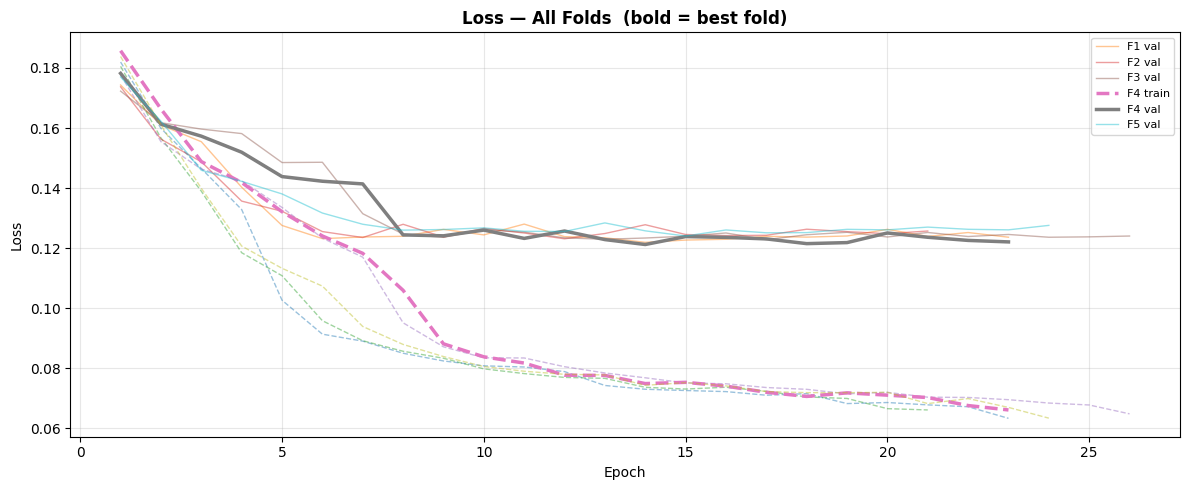

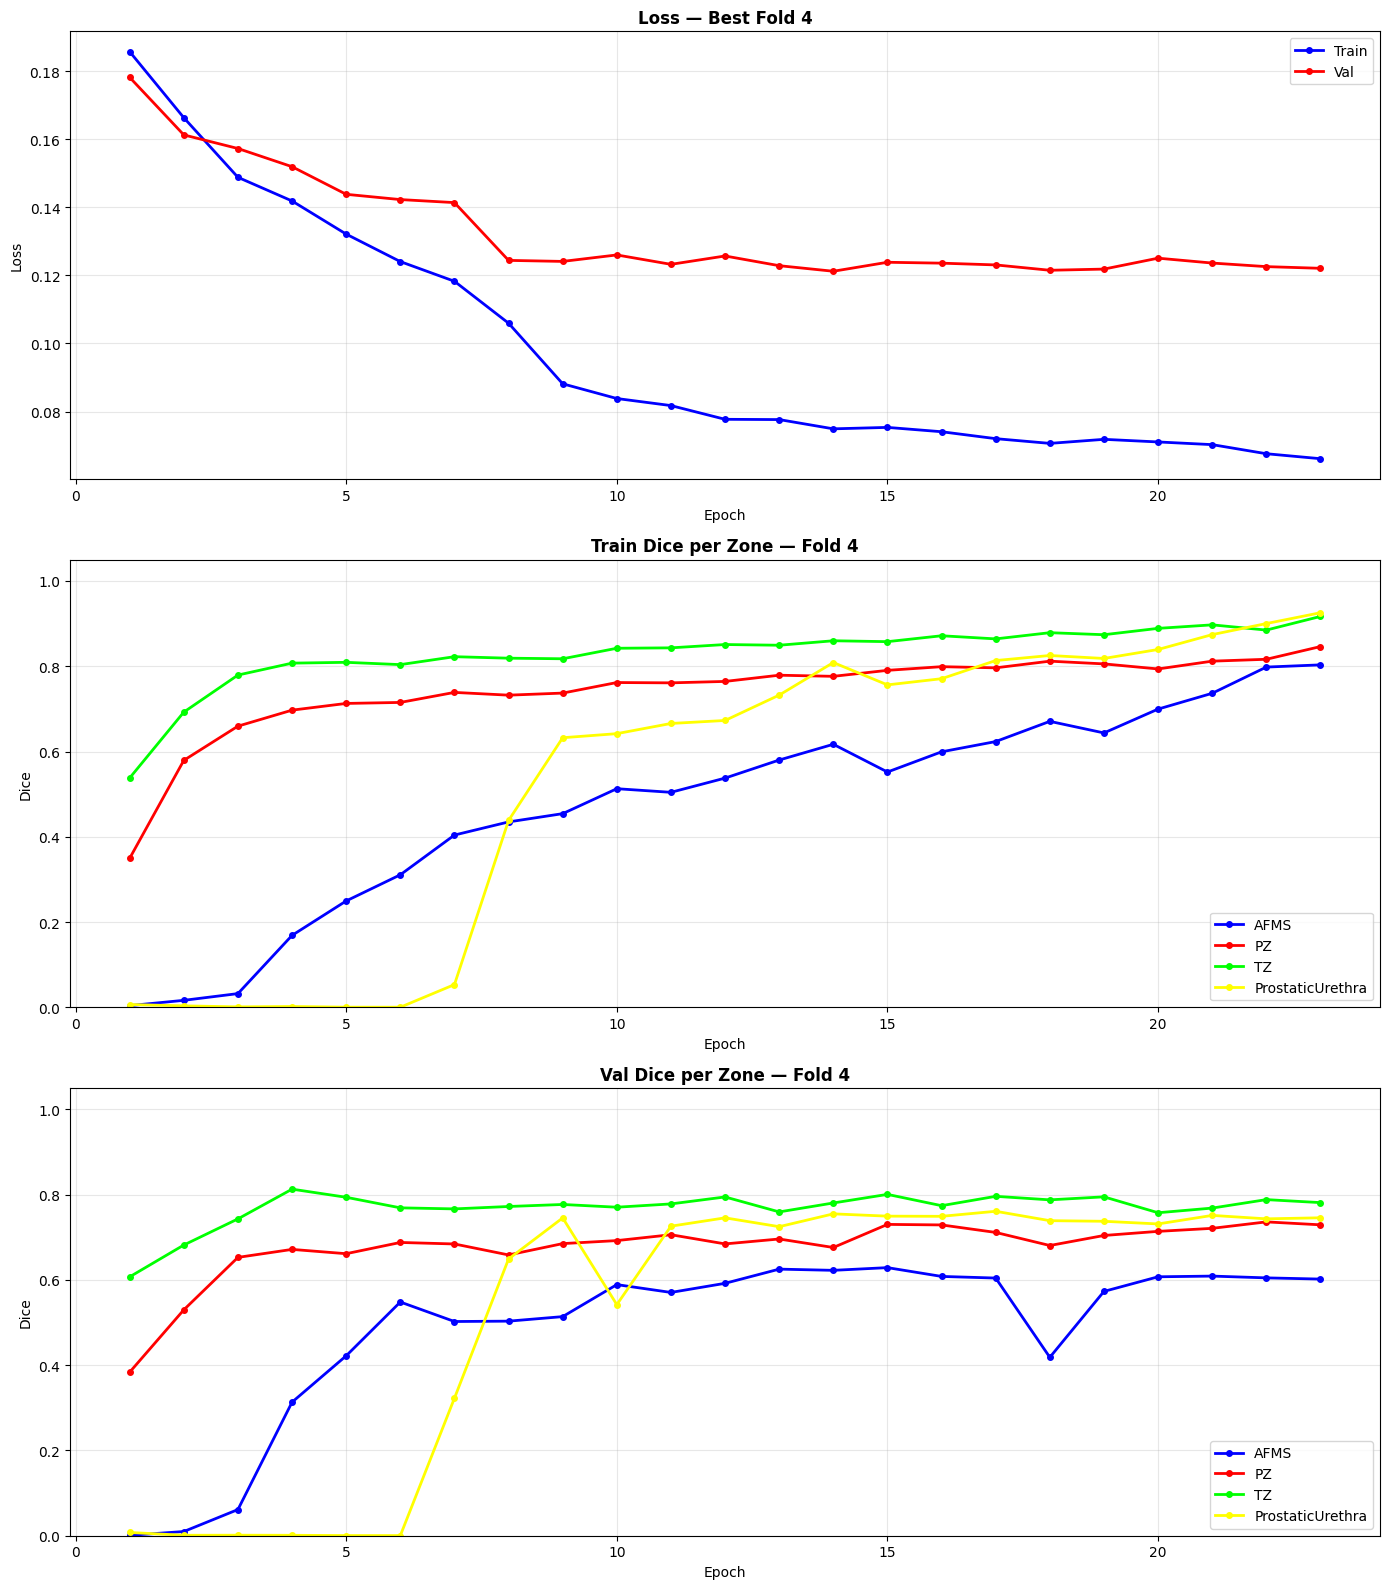

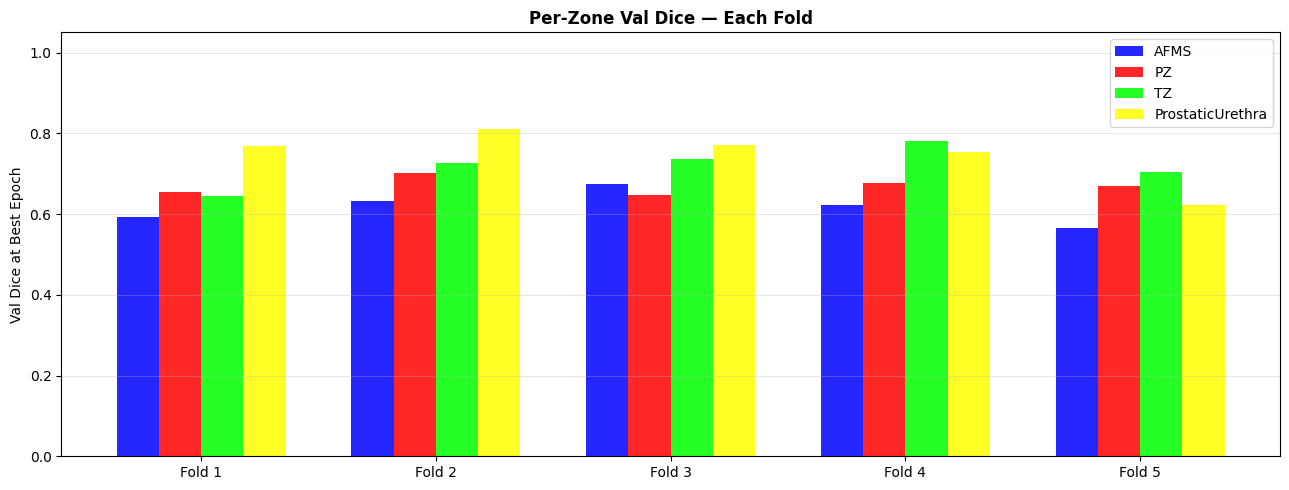

Training plots saved to AttentionUNet_HRNetW32\plots/


In [7]:
# =============================================================================
# CELL 9 — Training curves
# =============================================================================
def plot_training_curves(fold_histories, kfold_summary):
    plots_dir = os.path.join(SAVE_DIR, 'plots')
    best_fi   = min(range(len(kfold_summary['per_fold'])),
                    key=lambda i: kfold_summary['per_fold'][i]['val_loss'])
    fg_names  = CLASS_NAMES[1:]
    zone_clrs = ['#0000FF', '#FF0000', '#00FF00', '#FFFF00']

    # 1. Loss all folds
    plt.figure(figsize=(12, 5))
    for i, h in enumerate(fold_histories):
        ep = range(1, len(h['train_loss'])+1)
        lw, al = (2.5, 1.0) if i==best_fi else (1.0, 0.45)
        plt.plot(ep, h['train_loss'], '--', lw=lw, alpha=al,
                 label=f"F{i+1} train" if i==best_fi else None)
        plt.plot(ep, h['val_loss'],   '-',  lw=lw, alpha=al, label=f"F{i+1} val")
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title('Loss — All Folds  (bold = best fold)', fontweight='bold')
    plt.legend(fontsize=8); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'all_folds_loss.png'), dpi=300, bbox_inches='tight')
    plt.show(); plt.close()

    # 2. Best fold: loss + train dice + val dice
    h  = fold_histories[best_fi]
    ep = range(1, len(h['train_loss'])+1)
    fig, axes = plt.subplots(3, 1, figsize=(14, 16))
    axes[0].plot(ep, h['train_loss'], 'b-o', lw=2, ms=4, label='Train')
    axes[0].plot(ep, h['val_loss'],   'r-o', lw=2, ms=4, label='Val')
    axes[0].set_title(f'Loss — Best Fold {best_fi+1}', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    for n,c in zip(fg_names, zone_clrs):
        axes[1].plot(ep, h[f'train_dice_{n.lower()}'], '-o', lw=2, ms=4, label=n, color=c)
    axes[1].set_title(f'Train Dice per Zone — Fold {best_fi+1}', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Dice'); axes[1].set_ylim([0,1.05])
    axes[1].legend(loc='lower right'); axes[1].grid(True, alpha=0.3)
    for n,c in zip(fg_names, zone_clrs):
        axes[2].plot(ep, h[f'val_dice_{n.lower()}'], '-o', lw=2, ms=4, label=n, color=c)
    axes[2].set_title(f'Val Dice per Zone — Fold {best_fi+1}', fontweight='bold')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Dice'); axes[2].set_ylim([0,1.05])
    axes[2].legend(loc='lower right'); axes[2].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, f'training_curves_best_fold{best_fi+1}.png'),
                dpi=300, bbox_inches='tight')
    plt.show(); plt.close()

    # 3. Per-fold dice bar
    x = np.arange(K_FOLDS); width = 0.18
    fig, ax = plt.subplots(figsize=(13, 5))
    for j,(n,c) in enumerate(zip(fg_names, zone_clrs)):
        vals = [kfold_summary['per_fold'][i][n] for i in range(K_FOLDS)]
        ax.bar(x+j*width, vals, width, label=n, color=c, alpha=0.85)
    ax.set_xticks(x+width*1.5); ax.set_xticklabels([f'Fold {i+1}' for i in range(K_FOLDS)])
    ax.set_ylabel('Val Dice at Best Epoch'); ax.set_ylim([0,1.05])
    ax.set_title('Per-Zone Val Dice — Each Fold', fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'per_fold_dice_bar.png'), dpi=300, bbox_inches='tight')
    plt.show(); plt.close()
    print(f"Training plots saved to {plots_dir}/")


plot_training_curves(fold_histories, kfold_summary)

In [17]:
import os

# 1. Ensure SAVE_DIR is defined (change this to your actual directory name if it's different)
SAVE_DIR = "AttentionUNet_HRNetW32" 

# 2. Manually point to your best model file
# (Check your 'checkpoints' folder to see the exact name of your saved .pth file)
best_model_path = os.path.join(SAVE_DIR, "best_model.pth")

print(f"Manually set best_model_path to: {best_model_path}")

Manually set best_model_path to: AttentionUNet_HRNetW32\best_model.pth


In [18]:
# =============================================================================
# CELL 10 — Test-set evaluation
# =============================================================================
def evaluate_on_test(model_path, test_dataset, num_vis_patients=5,
                     model_name='AttnUNet-HRNetW32'):
    vis_dir = os.path.join(SAVE_DIR, 'visuals', model_name)
    os.makedirs(vis_dir, exist_ok=True)

    model = AttentionUNetHRNetW32(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()
    print(f"Loaded {model_name} from {model_path}")

    # Use batch_size=1 to easily map metadata to the specific slice
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)
    
    # Select the 5 patients to visualize fully
    random.seed(SEED)
    vis_patients = set(random.sample(test_dataset.patient_ids, 
                                     min(num_vis_patients, len(test_dataset.patient_ids))))
    print(f"Visualizing all slices for patients: {vis_patients}")

    total_dice = np.zeros(NUM_CLASSES); total_slices = 0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Test eval'):
            imgs, masks, pids, sls = batch
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            
            # Since batch_size=1, extract the single values
            pid = pids[0]
            sl  = sls[0].item()

            out   = model(imgs)
            preds = torch.argmax(F.softmax(out, dim=1), dim=1)

            # Standard Metrics Calculation
            for c in range(NUM_CLASSES):
                p = (preds==c).float(); t = (masks==c).float()
                total_dice[c] += ((2*(p*t).sum()+1e-6)/(p.sum()+t.sum()+1e-6)).item()
            total_slices += 1

            # Visualization Logic: Save EVERY slice if the patient is in our target set
            if pid in vis_patients:
                img_np  = np.rot90(imgs[0,0].cpu().numpy(), k=1)
                pred_np = np.rot90(preds[0].cpu().numpy(),  k=1)
                mask_np = np.rot90(masks[0].cpu().numpy(),  k=1)
                
                # Normalize MRI for display
                bg = ((img_np-img_np.min())/(img_np.max()-img_np.min()+1e-8)*255).astype(np.uint8)
                bg_rgb = np.stack([bg]*3, axis=-1); alpha = 0.45
                
                # Apply color maps
                ov_gt   = ((1-alpha)*bg_rgb + alpha*COLORS[mask_np]).astype(np.uint8)
                ov_pred = ((1-alpha)*bg_rgb + alpha*COLORS[pred_np]).astype(np.uint8)
                
                fig, axes = plt.subplots(1, 3, figsize=(15,5))
                axes[0].imshow(bg, cmap='gray'); axes[0].set_title(f'MRI {pid} sl={sl}')
                axes[1].imshow(ov_gt);           axes[1].set_title('Ground Truth')
                axes[2].imshow(ov_pred);         axes[2].set_title('Prediction')
                for ax in axes: ax.axis('off')
                
                plt.tight_layout()
                # Filename includes patient number and slice number
                plt.savefig(os.path.join(vis_dir, f'{pid}_slice{sl:03d}.png'),
                            dpi=150, bbox_inches='tight')
                plt.close()

    avg     = total_dice / total_slices
    mean_fg = float(np.mean(avg[1:]))
    
    # Final Reporting
    print(f"\n{'='*55}\n  TEST RESULTS\n{'='*55}")
    for c,n in enumerate(CLASS_NAMES): print(f"  {n:22s}: {avg[c]:.4f}")
    print(f"  {'Mean Dice (FG)':22s}: {mean_fg:.4f}\n{'='*55}")

    test_metrics = {'per_class': {n: float(avg[c]) for c,n in enumerate(CLASS_NAMES)},
                    'mean_dice_fg': mean_fg}
    with open(os.path.join(SAVE_DIR, 'test_metrics.json'), 'w') as f:
        json.dump(test_metrics, f, indent=2)
    
    return avg, mean_fg

# Execute
test_dice, mean_dice_fg = evaluate_on_test(best_model_path, test_dataset)

Loaded AttnUNet-HRNetW32 from AttentionUNet_HRNetW32\best_model.pth
Visualizing all slices for patients: {'ProstateX-0033', 'ProstateX-0193', 'ProstateX-0199', 'ProstateX-0059', 'ProstateX-0288'}


Test eval: 100%|██████████| 393/393 [02:10<00:00,  3.02it/s]


  TEST RESULTS
  Background            : 0.9975
  AFMS                  : 0.6656
  PZ                    : 0.7303
  TZ                    : 0.7859
  ProstaticUrethra      : 0.8068
  Mean Dice (FG)        : 0.7471


Confusion matrix: 100%|██████████| 393/393 [01:44<00:00,  3.77it/s]


Saved: AttentionUNet_HRNetW32\plots\confusion_matrix.png


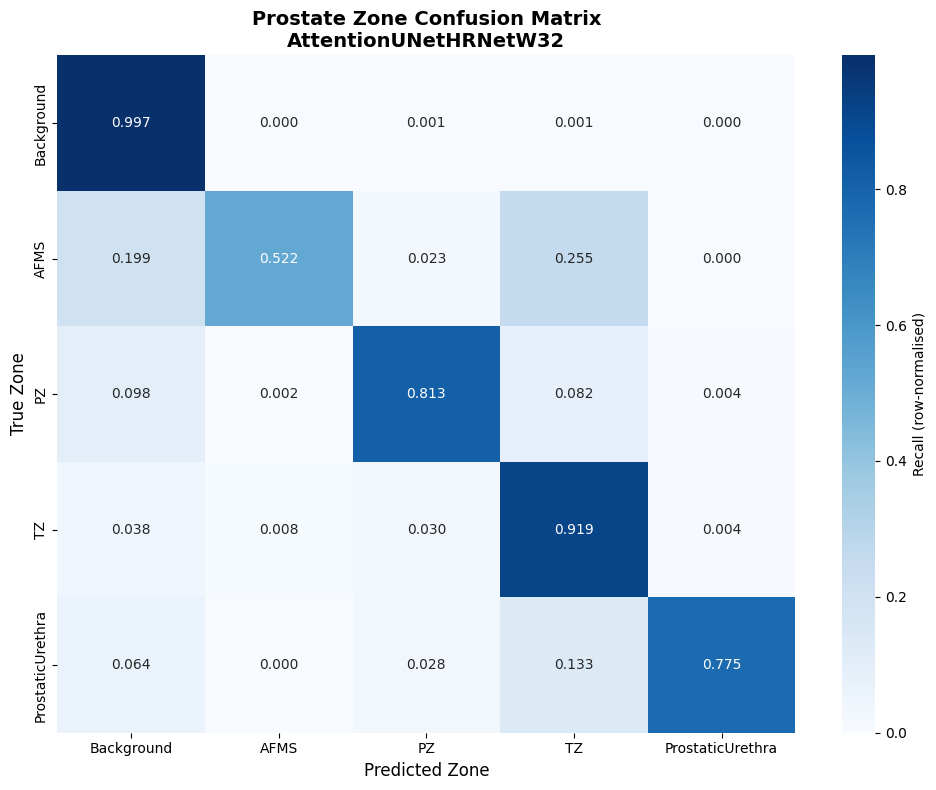

In [19]:
import seaborn as sns
# =============================================================================
# CELL 11 — Confusion matrix
# =============================================================================
def plot_confusion_matrix(model_path, test_dataset, model_name='AttentionUNetHRNetW32'):
    model = AttentionUNetHRNetW32(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0) # Also set num_workers=0 here for Windows!

    all_preds, all_targets = [], []
    with torch.no_grad():
        # CHANGED: Unpack all 4 values here
        for imgs, masks, pids, sls in tqdm(test_loader, desc='Confusion matrix'):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = torch.argmax(F.softmax(model(imgs), dim=1), dim=1)
            all_preds.extend(preds.view(-1).cpu().numpy())
            all_targets.extend(masks.view(-1).cpu().numpy())

    cm   = confusion_matrix(all_targets, all_preds, labels=range(NUM_CLASSES))
    cm_n = cm.astype('float') / (cm.sum(axis=1)[:,None] + 1e-6)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_n, annot=True, fmt='.3f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cbar_kws={'label': 'Recall (row-normalised)'})
    plt.ylabel('True Zone', fontsize=12); plt.xlabel('Predicted Zone', fontsize=12)
    plt.title(f'Prostate Zone Confusion Matrix\n{model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(SAVE_DIR, 'plots', 'confusion_matrix.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_path}")
    plt.show()
    return cm, cm_n

best_model_path=r"AttentionUNet_HRNetW32\best_model.pth"
cm, cm_norm = plot_confusion_matrix(best_model_path, test_dataset)

In [20]:
import os
import json
import torch
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader

# --- 1. Validation Set Evaluation (From JSON) ---
print("======================================================")
print("  VALIDATION SET RESULTS (Per-Fold Best Epoch)")
print("======================================================")

val_losses = []
val_dices_per_class = {cls: [] for cls in CLASS_NAMES}

for fold_idx in range(1, K_FOLDS + 1):
    json_path = f"{SAVE_PREFIX}_fold{fold_idx}_metrics.json"
    
    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            history = json.load(f)
            
        # Find the epoch with the lowest validation loss
        best_ep = np.argmin(history['val_loss'])
        best_loss = history['val_loss'][best_ep]
        val_losses.append(best_loss)
        
        print(f"\\n[Fold {fold_idx}] Validation Loss: {best_loss:.4f} (Epoch {best_ep + 1})")
        for cls in CLASS_NAMES:
            # Metrics were saved lowercase in your train_one_fold function
            cls_dice = history[f'val_dice_{cls.lower()}'][best_ep]
            val_dices_per_class[cls].append(cls_dice)
            print(f"  - {cls:16s}: {cls_dice:.4f}")

# --- 2. Test Set Evaluation (Inference) ---
print("\\n======================================================")
print("  TEST SET RESULTS (Evaluated on Unseen Patients)")
print("======================================================")

# Create a DataLoader for the test dataset defined in Cell 3
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
criterion = DiceFocalLoss(n_classes=NUM_CLASSES, class_weights=CLASS_WEIGHTS)

test_losses = []
test_dices_per_class = {cls: [] for cls in CLASS_NAMES}

for fold_idx in range(1, K_FOLDS + 1):
    # Initialize model and load weights
    model = AttentionUNetHRNetW32(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)
    weights_path = f"{SAVE_PREFIX}_fold{fold_idx}_best.pth"
    
    if not os.path.exists(weights_path):
        print(f"Weights not found: {weights_path}")
        continue
        
    model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    model.eval()
    
    fold_test_loss = 0.0
    fold_test_dices = [0.0] * NUM_CLASSES
    
    with torch.no_grad():
        for imgs, masks, pids, sls in tqdm(test_loader, leave=False, desc=f"Testing Fold {fold_idx}"):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            
            out = model(imgs)
            loss = criterion(out, masks)
            fold_test_loss += loss.item()
            
            bd = get_batch_dice(out, masks, NUM_CLASSES)
            for c in range(NUM_CLASSES): 
                fold_test_dices[c] += bd[c].item() if hasattr(bd[c], 'item') else bd[c]
                
    # Averages for this fold
    n_test = len(test_loader)
    avg_test_loss = fold_test_loss / n_test
    avg_test_dices = [d / n_test for d in fold_test_dices]
    
    test_losses.append(avg_test_loss)
    
    print(f"\\n[Fold {fold_idx}] Test Loss: {avg_test_loss:.4f}")
    for i, cls in enumerate(CLASS_NAMES):
        test_dices_per_class[cls].append(avg_test_dices[i])
        print(f"  - {cls:16s}: {avg_test_dices[i]:.4f}")

# --- 3. Overall Averages Summary ---
print("\\n======================================================")
print("  CROSS VALIDATION AVERAGES (Mean ± Std)")
print("======================================================")
print("--- Validation Set Averages ---")
print(f"Overall Val Loss: {np.mean(val_losses):.4f} ± {np.std(val_losses):.4f}")
for cls in CLASS_NAMES:
    print(f"  - {cls:16s}: {np.mean(val_dices_per_class[cls]):.4f} ± {np.std(val_dices_per_class[cls]):.4f}")

print("\\n--- Test Set Averages ---")
print(f"Overall Test Loss: {np.mean(test_losses):.4f} ± {np.std(test_losses):.4f}")
for cls in CLASS_NAMES:
    print(f"  - {cls:16s}: {np.mean(test_dices_per_class[cls]):.4f} ± {np.std(test_dices_per_class[cls]):.4f}") 

  VALIDATION SET RESULTS (Per-Fold Best Epoch)
\n[Fold 1] Validation Loss: 0.1220 (Epoch 14)
  - Background      : 0.9974
  - AFMS            : 0.5923
  - PZ              : 0.6549
  - TZ              : 0.6455
  - ProstaticUrethra: 0.7692
\n[Fold 2] Validation Loss: 0.1231 (Epoch 12)
  - Background      : 0.9975
  - AFMS            : 0.6316
  - PZ              : 0.7013
  - TZ              : 0.7275
  - ProstaticUrethra: 0.8109
\n[Fold 3] Validation Loss: 0.1228 (Epoch 17)
  - Background      : 0.9981
  - AFMS            : 0.6751
  - PZ              : 0.6474
  - TZ              : 0.7374
  - ProstaticUrethra: 0.7714
\n[Fold 4] Validation Loss: 0.1212 (Epoch 14)
  - Background      : 0.9971
  - AFMS            : 0.6224
  - PZ              : 0.6759
  - TZ              : 0.7804
  - ProstaticUrethra: 0.7548
\n[Fold 5] Validation Loss: 0.1241 (Epoch 15)
  - Background      : 0.9975
  - AFMS            : 0.5643
  - PZ              : 0.6696
  - TZ              : 0.7039
  - ProstaticUrethra: 0.621

\n[Fold 1] Test Loss: 0.1216
  - Background      : 0.9974
  - AFMS            : 0.6176
  - PZ              : 0.6618
  - TZ              : 0.6575
  - ProstaticUrethra: 0.7195


\n[Fold 2] Test Loss: 0.1201
  - Background      : 0.9976
  - AFMS            : 0.5894
  - PZ              : 0.7323
  - TZ              : 0.7506
  - ProstaticUrethra: 0.7238


\n[Fold 3] Test Loss: 0.1232
  - Background      : 0.9976
  - AFMS            : 0.6182
  - PZ              : 0.6430
  - TZ              : 0.7820
  - ProstaticUrethra: 0.7608


\n[Fold 4] Test Loss: 0.1213
  - Background      : 0.9976
  - AFMS            : 0.6376
  - PZ              : 0.7035
  - TZ              : 0.7645
  - ProstaticUrethra: 0.7635


\n[Fold 5] Test Loss: 0.1203
  - Background      : 0.9974
  - AFMS            : 0.5394
  - PZ              : 0.6640
  - TZ              : 0.7289
  - ProstaticUrethra: 0.5980
\n======================================================
  CROSS VALIDATION AVERAGES (Mean ± Std)
--- Validation Set Averages ---
Overall Val Loss: 0.1226 ± 0.0010
  - Background      : 0.9975 ± 0.0003
  - AFMS            : 0.6171 ± 0.0374
  - PZ              : 0.6698 ± 0.0187
  - TZ              : 0.7189 ± 0.0443
  - ProstaticUrethra: 0.7455 ± 0.0649
\n--- Test Set Averages ---
Overall Test Loss: 0.1213 ± 0.0011
  - Background      : 0.9975 ± 0.0001
  - AFMS            : 0.6004 ± 0.0342
  - PZ              : 0.6809 ± 0.0324
  - TZ              : 0.7367 ± 0.0433
  - ProstaticUrethra: 0.7131 ± 0.0604


In [21]:
import os
import json
import numpy as np

# --- Configuration ---
SAVE_DIR = "AttentionUNet_HRNetW32"
SAVE_PREFIX = os.path.join(SAVE_DIR, 'checkpoints', 'attn_unet_hrnetw32')
CLASS_NAMES = ['Background', 'AFMS', 'PZ', 'TZ', 'ProstaticUrethra']
FOREGROUND_CLASSES = ['AFMS', 'PZ', 'TZ', 'ProstaticUrethra'] # Exclude background for Mean Dice
K_FOLDS = 5

print("======================================================")
print("  PER-FOLD VALIDATION DICE & LOSS (From JSON)")
print("======================================================")

val_losses = []
val_mean_dices = []
val_dices_per_class = {cls: [] for cls in FOREGROUND_CLASSES}

for fold_idx in range(1, K_FOLDS + 1):
    json_path = f"{SAVE_PREFIX}_fold{fold_idx}_metrics.json"
    
    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            history = json.load(f)
            
        # Find the epoch with the lowest validation loss
        best_ep = np.argmin(history['val_loss'])
        best_loss = history['val_loss'][best_ep]
        val_losses.append(best_loss)
        
        # Calculate the mean dice for this fold (foreground only)
        fold_dice_scores = [history[f'val_dice_{cls.lower()}'][best_ep] for cls in FOREGROUND_CLASSES]
        fold_mean_dice = np.mean(fold_dice_scores)
        val_mean_dices.append(fold_mean_dice)
        
        print(f"\n[Fold {fold_idx}] Epoch {best_ep + 1}")
        print(f"  - Val Loss: {best_loss:.4f}")
        print(f"  - Mean Val Dice: {fold_mean_dice:.4f} (Foreground Avg)")
        
        # Print the breakdown per zone
        for cls in FOREGROUND_CLASSES:
            cls_dice = history[f'val_dice_{cls.lower()}'][best_ep]
            val_dices_per_class[cls].append(cls_dice)
            print(f"      > {cls:16s}: {cls_dice:.4f}")
    else:
        print(f"Metrics file not found for Fold {fold_idx}: {json_path}")

print("\n======================================================")
print("  VALIDATION SET CROSS-VALIDATION SUMMARY")
print("======================================================")
print(f"Average CV Val Loss:      {np.mean(val_losses):.4f} ± {np.std(val_losses):.4f}")
print(f"Average CV Mean Val Dice: {np.mean(val_mean_dices):.4f} ± {np.std(val_mean_dices):.4f}")

print("\n--- Zone-Specific Average CV Dice ---")
for cls in FOREGROUND_CLASSES:
    print(f"  - {cls:16s}: {np.mean(val_dices_per_class[cls]):.4f} ± {np.std(val_dices_per_class[cls]):.4f}")

  PER-FOLD VALIDATION DICE & LOSS (From JSON)

[Fold 1] Epoch 14
  - Val Loss: 0.1220
  - Mean Val Dice: 0.6655 (Foreground Avg)
      > AFMS            : 0.5923
      > PZ              : 0.6549
      > TZ              : 0.6455
      > ProstaticUrethra: 0.7692

[Fold 2] Epoch 12
  - Val Loss: 0.1231
  - Mean Val Dice: 0.7178 (Foreground Avg)
      > AFMS            : 0.6316
      > PZ              : 0.7013
      > TZ              : 0.7275
      > ProstaticUrethra: 0.8109

[Fold 3] Epoch 17
  - Val Loss: 0.1228
  - Mean Val Dice: 0.7078 (Foreground Avg)
      > AFMS            : 0.6751
      > PZ              : 0.6474
      > TZ              : 0.7374
      > ProstaticUrethra: 0.7714

[Fold 4] Epoch 14
  - Val Loss: 0.1212
  - Mean Val Dice: 0.7084 (Foreground Avg)
      > AFMS            : 0.6224
      > PZ              : 0.6759
      > TZ              : 0.7804
      > ProstaticUrethra: 0.7548

[Fold 5] Epoch 15
  - Val Loss: 0.1241
  - Mean Val Dice: 0.6397 (Foreground Avg)
      > AFM